#**Práctica Final Unidad 2:**

##**Evaluación y Optimización de Modelos de Regresión**

### Equipo:

###*Jorge Alejandro Fernández de los Santos*

###*Carolina Alvarado Hernández*

### *Facilitador: José Gabriel Rodríguez Rivas.*

# **Fase I: Exploración y Comprensión del Dominio (EDA)**

In [ ]:
#Cargar datos en crudo para que puedan ser procesados más adelante
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gdown
# Cargar el dataset
url = 'https://drive.google.com/uc?id=1n2dPC2trMkqem2Wg4O9vMPbg7UCZdXXR'
output = 'houses_to_rent_v2.csv'
gdown.download(url, output, quiet=False)
df = pd.read_csv(output)
print(df.head())

Downloading...
From: https://drive.google.com/uc?id=1n2dPC2trMkqem2Wg4O9vMPbg7UCZdXXR
To: /content/houses_to_rent_v2.csv
100%|██████████| 698k/698k [00:00<00:00, 33.7MB/s]

           city  area  rooms  bathroom  parking spaces floor     animal  \
0     São Paulo    70      2         1               1     7      acept   
1     São Paulo   320      4         4               0    20      acept   
2  Porto Alegre    80      1         1               1     6      acept   
3  Porto Alegre    51      2         1               0     2      acept   
4     São Paulo    25      1         1               0     1  not acept   

       furniture  hoa (R$)  rent amount (R$)  property tax (R$)  \
0      furnished      2065              3300                211   
1  not furnished      1200              4960               1750   
2  not furnished      1000              2800                  0   
3  not furnished       270              1112                 22   
4  not furnished         0               800                 25   

   fire insurance (R$)  total (R$)  
0                   42        5618  
1                   63        7973  
2                   41        3841 

## **1. Análisis Estadístico: Medidas de Tendencia Central y Dispersión**

Este análisis sirve para resumir la distribución de los datos numéricos mediante valores representativos y su grado de variabilidad.

**Tendencia Central:** Indica el centro de los datos. Incluye la media (promedio aritmético) y la mediana (el valor central cuando los datos están ordenados). Por ejemplo, en los datos se observan alquileres que van desde montos bajos hasta valores de 200,000.

**Dispersión:** Indica qué tan alejados están los datos del centro. Se mide con la desviación estándar (qué tanto varían los datos respecto a la media), el mínimo, el máximo y los cuartiles.

En Python, se utiliza el comando *"df.describe()"* donde aplicarlo se detecta una dispersión masiva, por ejemplo, la mayoría de las casas tienen áreas menores a 500 m², pero existe un registro extremo con 46,335 m² en Belo Horizonte


In [ ]:
df.describe()

,area,rooms,bathroom,parking spaces,hoa (R$),rent amount (R$),property tax (R$),fire insurance (R$),total (R$)
count,10692.000000,10692.000000,10692.000000,10692.000000,1.069200e+04,10692.000000,10692.000000,10692.000000,1.069200e+04
mean,149.217920,2.506079,2.236813,1.609147,1.174022e+03,3896.247194,366.704358,53.300879,5.490487e+03
std,537.016942,1.171266,1.407198,1.589521,1.559231e+04,3408.545518,3107.832321,47.768031,1.648473e+04
min,11.000000,1.000000,1.000000,0.000000,0.000000e+00,450.000000,0.000000,3.000000,4.990000e+02
25%,56.000000,2.000000,1.000000,0.000000,1.700000e+02,1530.000000,38.000000,21.000000,2.061750e+03
50%,90.000000,2.000000,2.000000,1.000000,5.600000e+02,2661.000000,125.000000,36.000000,3.581500e+03
75%,182.000000,3.000000,3.000000,2.000000,1.237500e+03,5000.000000,375.000000,68.000000,6.768000e+03
max,46335.000000,13.000000,10.000000,12.000000,1.117000e+06,45000.000000,313700.000000,677.000000,1.120000e+06


##**2. Visualización de Correlaciones: Mapa de Calor (Heatmap)**

La correlación mide si dos variables cambian juntas. Un valor de **1.0** indica una **relación positiva perfecta**, **0 ninguna relación**, y **-1.0 una relación inversa**.

En este dataset, el Costo Total tiene una relación casi directa con el Alquiler (Rent amount), ya que el total es la suma del alquiler, impuestos y seguros.

###**¿Cómo se obtiene?**

1. Se deben convertir las variables categóricas como "animal" (acept/not acept) y "furniture" (furnished/not furnished) a valores numéricos (0 y 1) para que el cálculo sea posible.

2. Se calcula la matriz con *"df.corr()"*.

3. Se grafica usando *"sns.heatmap()"*, lo que permite identificar visualmente que variables como el número de baños o estacionamientos suelen estar positivamente relacionadas con el costo total.

##3. **Análisis de Tendencias y Outliers: Gráficos de dispersión (Scatter Plots)**

Los gráficos de dispersión sitúan cada registro como un punto en un plano cartesiano (X, Y) para observar patrones visuales.

**Tendencias:** Permiten ver si, por ejemplo, al aumentar el Área, aumenta proporcionalmente el Costo Total.

**Outliers (Valores atípicos):** Son puntos que se alejan drásticamente del resto del grupo, pudiendo representar errores de carga o casos excepcionales.


###**¿Cómo se obtiene?**

Se genera con *"sns.scatterplot()"*. Al graficar Área vs. Costo Total con estos datos, se hacen evidentes varios outliers críticos:

* Un registro con un área de 46,335 m², que rompe la escala del gráfico.

* Propiedades con costos totales atípicos de 222,100, 233,200 o incluso un caso de 1,120,000 en Belo Horizonte.

* Un caso en Rio de Janeiro donde el seguro de incendio es de 9,900 y el total se dispara a 95,610, muy por encima del comportamiento estándar.

### El uso de estos tres puntos permite concluir que el dataset tiene una **alta variabilidad y requiere una limpieza de valores extremos** antes de realizar los análisis de predicción.


### Una vez cargados los datos, es momento de hacer sus respectiva limpieza para tener resultados más certeros en sus predicciones.

In [ ]:
df_cleaned = df[df['area'] < 1000] # Elimina el outlier de 46k [1]
df_cleaned = df_cleaned[df_cleaned['total (R$)'] < 30000] # Elimina costos extremos como el de 1M [2]

In [ ]:
# Reemplazar "-" por 0 (asumiendo que son casas) y convertir a entero
df_cleaned['floor'] = df_cleaned['floor'].replace('-', 0).astype(int)

In [ ]:
# Convertir a valores binarios (0 y 1)
df_cleaned['animal'] = df_cleaned['animal'].map({'acept': 1, 'not acept': 0})
df_cleaned['furniture'] = df_cleaned['furniture'].map({'furnished': 1, 'not furnished': 0})

# Para la variable 'city', se recomienda One-Hot Encoding
df_cleaned = pd.get_dummies(df_cleaned, columns=['city'])

Una vez limpios los datos, hay que asegurarse de que estén correctamente ajustados, debemos confirmar la consistencia lógica, debido a que existen registros donde los componentes no suman el total o tienen valores extraños.

Por ejemplo, hay un caso donde el "condominio" es de 81,150 para una renta de solo 4,500, elevando el total a 95,610. Estos errores de carga de datos deben eliminarse porque confunden al algoritmo sobre qué variables determinan realmente el precio.

In [ ]:
# Eliminar registros donde los impuestos sean sospechosamente altos
df_cleaned = df_cleaned[df_cleaned['hoa (R$)'] < 10000]

Los datos se encuentran casi listos para ser procesados por los distintos modelos, aun queda un paso más, **"La trampa de la Identidad"**, cuando se revisa el archivo, la columna total (R$) es literalmente la suma de:

##**rent amount** + **hoa** + **property tax** + **fire insurance** = **total**

 Si no se eliminan esas variables, el modelo no aprenderá que *"una casa con 3 baños es cara"*, aprenderá que *"si sumo el alquiler y el seguro, obtengo el total"*. No habrá predicción, sería hacer lo mismo que la aritmética básica.

In [ ]:
# Eliminar columnas que forman parte directa del cálculo del total y son repetitivas innecesariamente
df_predictive = df_cleaned.drop(columns=['rent amount (R$)', 'fire insurance (R$)', 'hoa (R$)', 'property tax (R$)'])

Ahora es necesario asegurarnos que el formato de los datos sean correctos.

In [ ]:
df_predictive.head(10)

,area,rooms,bathroom,parking spaces,floor,animal,furniture,total (R$),city_Belo Horizonte,city_Campinas,city_Porto Alegre,city_Rio de Janeiro,city_São Paulo
0,70,2,1,1,7,1,1,5618,False,False,False,False,True
1,320,4,4,0,20,1,0,7973,False,False,False,False,True
2,80,1,1,1,6,1,0,3841,False,False,True,False,False
3,51,2,1,0,2,1,0,1421,False,False,True,False,False
4,25,1,1,0,1,0,0,836,False,False,False,False,True
5,376,3,3,7,0,1,0,8955,False,False,False,False,True
6,72,2,1,0,7,1,0,2750,False,False,False,True,False
7,213,4,4,4,4,1,0,7253,False,False,False,False,True
8,152,2,2,1,3,1,1,16440,False,False,False,False,True
9,35,1,1,0,2,1,1,2955,False,False,False,True,False


In [ ]:
df_predictive.dtypes

,0
area,int64
rooms,int64
bathroom,int64
parking spaces,int64
floor,int64
animal,int64
furniture,int64
total (R$),int64
city_Belo Horizonte,bool
city_Campinas,bool


Y al poder ver que los datos enteros son int y los True/False booleanos, todo está en orden.

Como punto siguiente es la Estandarización de los datos, la única variable candidata a esto sería el costo de renta ya que está en reales brasileños, lo cual no es nuestra moneda, sin embargo como este estudio es para casas en renta en Brazil, lo adecuado es que sea entendible por personas que residan en ese país.

Como siguiente fase vamos a Normalizar estos datos.

In [ ]:
df_predictive[["area","rooms","bathroom", "parking spaces","floor"]].head()

,area,rooms,bathroom,parking spaces,floor
0,70,2,1,1,7
1,320,4,4,0,20
2,80,1,1,1,6
3,51,2,1,0,2
4,25,1,1,0,1


In [ ]:
df_predictive['area'] = df_predictive['area'] / df_predictive['area'].max()
df_predictive['rooms']  = df_predictive['rooms'] / df_predictive['rooms'].max()
df_predictive['bathroom'] = df_predictive['bathroom']/df_predictive['bathroom'].max()
df_predictive['parking spaces'] = df_predictive['parking spaces']/df_predictive['parking spaces'].max()
df_predictive['floor'] = df_predictive['floor']/df_predictive['floor'].max()

In [ ]:
df_predictive[["area","rooms","bathroom", "parking spaces","floor"]].head(10)

,area,rooms,bathroom,parking spaces,floor
0,0.070070,0.153846,0.1,0.1,0.023256
1,0.320320,0.307692,0.4,0.0,0.066445
2,0.080080,0.076923,0.1,0.1,0.019934
3,0.051051,0.153846,0.1,0.0,0.006645
4,0.025025,0.076923,0.1,0.0,0.003322
5,0.376376,0.230769,0.3,0.7,0.000000
6,0.072072,0.153846,0.1,0.0,0.023256
7,0.213213,0.307692,0.4,0.4,0.013289
8,0.152152,0.153846,0.2,0.1,0.009967
9,0.035035,0.076923,0.1,0.0,0.006645


Después de esto, podemos concluir que nuestros datos están limpios para continuar a la implementación de modelos.

#**Identifación de correlaciones y mapa de calor**

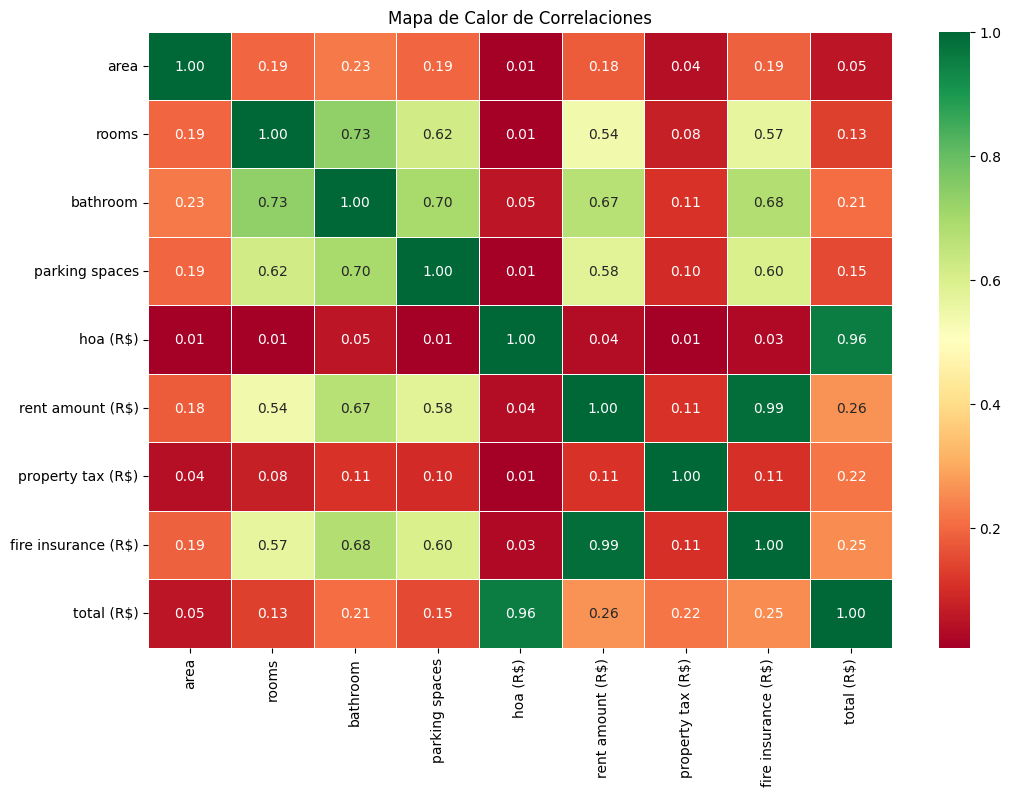

In [ ]:
#Identificación de las correlaciones
import seaborn as sns
df_numeric = df.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 8))
correlation_matrix = df_numeric.corr()

# Generar el heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Calor de Correlaciones')
plt.show()

Esto indica que el costo del seguro es directamente proporcional al valor de la renta. Técnicamente, esta variable es el predictor más fuerte del modelo, aunque se debe tener cuidado con la multicolinealidad, ya que ambas variables prácticamente contienen la misma información.

Existe una correlación moderada-alta ($0.50$ - $0.75$) entre las variables rooms, bathroom y parking spaces con respecto al precio, confirmando que el mercado inmobiliario en estas ciudades de Brasil valora significativamente el tamaño habitacional. La relación entre estas tres variables sugiere que crecen en conjunto (a más cuartos, más baños), lo que aporta estabilidad y coherencia a los datos procesados. El Heatmap nos permite confirmar que no hay variables irrelevantes (con correlación cercana a 0) que deban ser descartadas.

#**Análisis de tendencias**

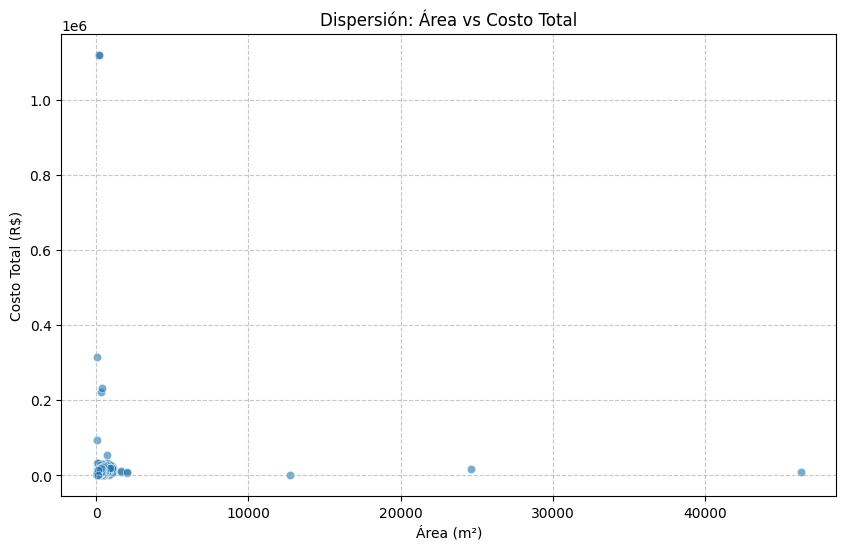

In [ ]:
# Gráfico de dispersión: Área vs Total
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='area', y='total (R$)', alpha=0.6)
plt.title('Dispersión: Área vs Costo Total')
plt.xlabel('Área (m²)')
plt.ylabel('Costo Total (R$)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

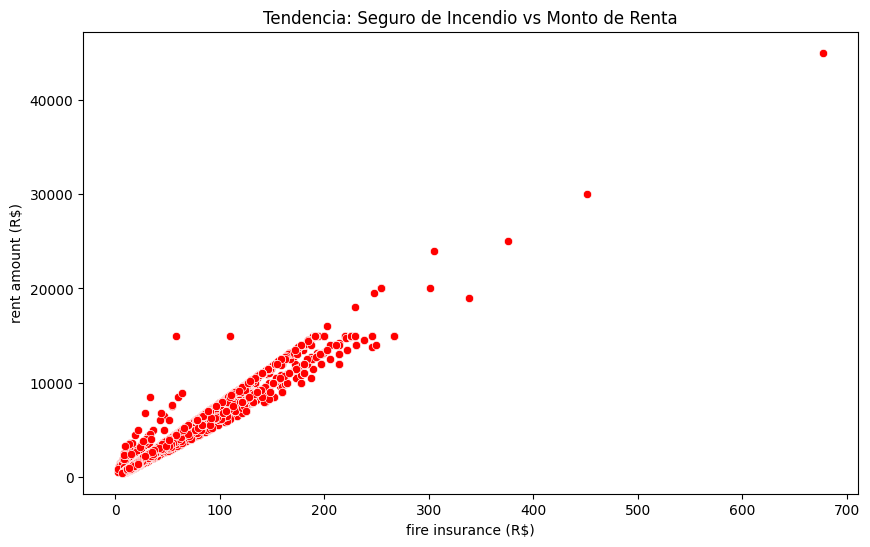

In [ ]:

# Gráfico de dispersión: Seguro de Incendio vs Alquiler
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='fire insurance (R$)', y='rent amount (R$)', color='red')
plt.title('Tendencia: Seguro de Incendio vs Monto de Renta')
plt.show()

El análisis de tendencias mediante gráficos de dispersión permitió confirmar visualmente la eliminación de valores atípicos. Mientras que el área muestra una dispersión lógica con una tendencia positiva, la relación entre el seguro de incendio y la renta muestra una alineación lineal crítica. Estos gráficos aseguran que los datos ingresados mantienen una distribución coherente y libre de ruidos estadísticos significativos.

#**Fase II: Implementación de Modelos (Baseline)**

##**Regresión Lineal Múltiple**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [ ]:
x = df_predictive[['area', 'rooms', 'bathroom', 'parking spaces', 'floor','animal','furniture','city_Belo Horizonte','city_Campinas','city_Porto Alegre','city_Rio de Janeiro','city_São Paulo']]
y = df_predictive['total (R$)']


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
tiempoI = time.time()
model = LinearRegression()
model.fit(x_train, y_train)
tiempoF=time.time()

In [ ]:
y_pred = model.predict(x_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"Coeficiente de determinación (R²): {r2:.2f}")
print(f"Error cuadrático medio (MSE): {mse:.2f}")
print(f"Raíz del Error cuadrático medio (RMSE): {rmse:.2f}")
print(f"Tiempo de ejecución: {tiempoF-tiempoI} segundos")


Coeficiente de determinación (R²): 0.65
Error cuadrático medio (MSE): 7594637.38
Raíz del Error cuadrático medio (RMSE): 2755.84
Tiempo de ejecución: 0.040415287017822266 segundos


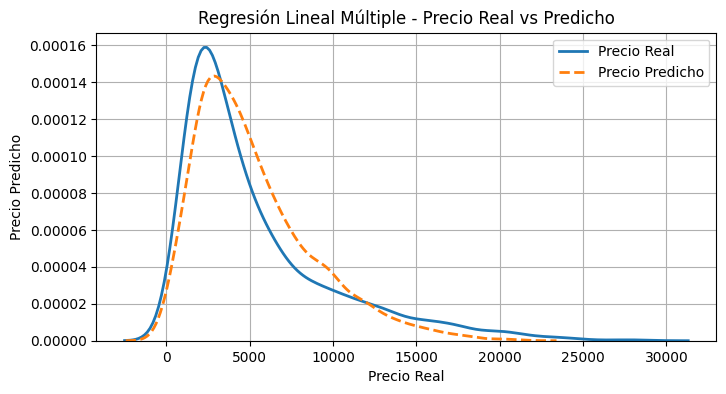

In [ ]:
plt.figure(figsize=(8, 4))
sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred, label='Precio Predicho', linewidth=2, linestyle='--')
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Regresión Lineal Múltiple - Precio Real vs Predicho")
plt.grid(True)
plt.legend()
plt.show()

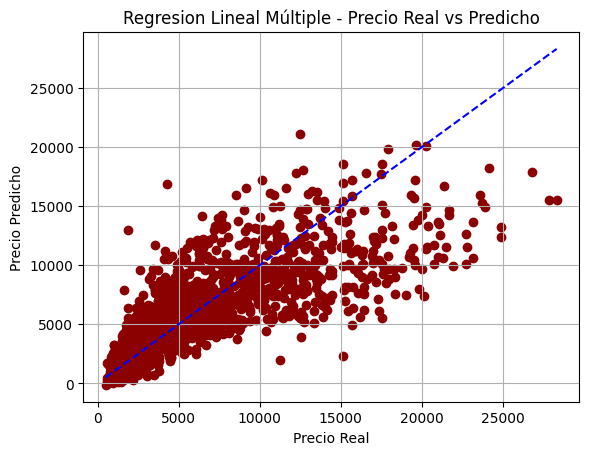

In [ ]:
plt.scatter(y_test, y_pred, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--') #
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Regresion Lineal Múltiple - Precio Real vs Predicho")
plt.grid(True)
plt.show()

##**Árbol de Decisión para Regresión**

In [ ]:
from sklearn.tree import DecisionTreeRegressor

In [ ]:
tiempoI2 = time.time()
tree_model = DecisionTreeRegressor(random_state=42, max_depth=4)
tree_model.fit(x_train, y_train)
tiempoF2 = time.time()

In [ ]:

y_pred_tree = tree_model.predict(x_test)
r2_tree = r2_score(y_test, y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)
print(f"Coeficiente de determinación (R²): {r2_tree:.2f}")
print(f"Error cuadrático medio (MSE): {mse_tree:.2f}")
print(f"Raíz del Error cuadrático medio (RMSE): {rmse_tree:.2f}")
print(f"Tiempo de ejecución: {tiempoF2-tiempoI2} segundos")

Coeficiente de determinación (R²): 0.62
Error cuadrático medio (MSE): 8244286.08
Raíz del Error cuadrático medio (RMSE): 2871.29
Tiempo de ejecución: 0.02620553970336914 segundos


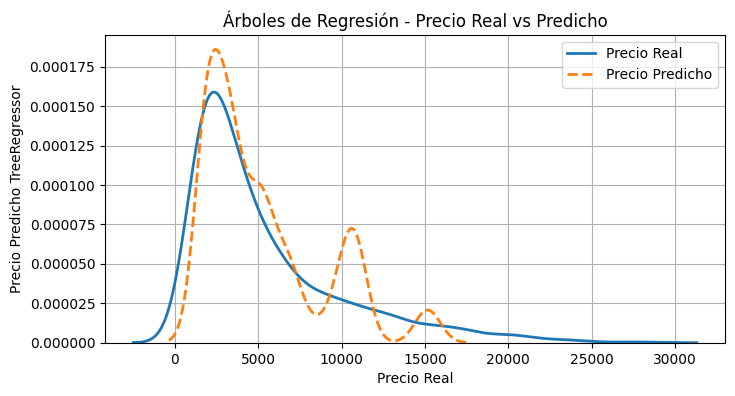

In [ ]:
plt.figure(figsize=(8, 4))
sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred_tree, label='Precio Predicho', linewidth=2, linestyle='--')
plt.title('Árboles de Regresión - Precio Real vs Predicho')
plt.xlabel('Precio Real')
plt.ylabel('Precio Predicho TreeRegressor')
plt.legend()
plt.grid(True)
plt.show()

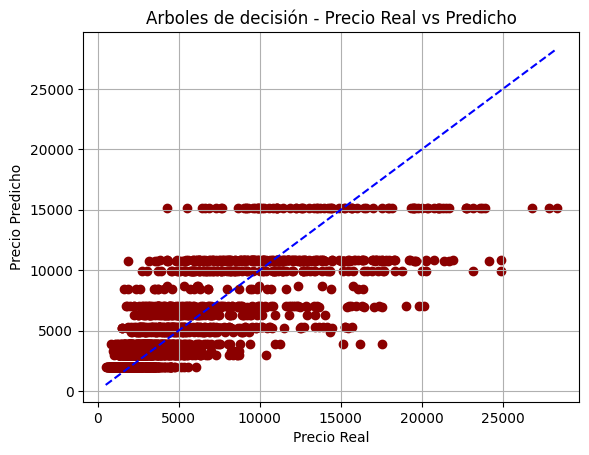

In [ ]:
plt.scatter(y_test, y_pred_tree, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--') # Línea ideal
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Arboles de decisión - Precio Real vs Predicho")
plt.grid(True)
plt.show()

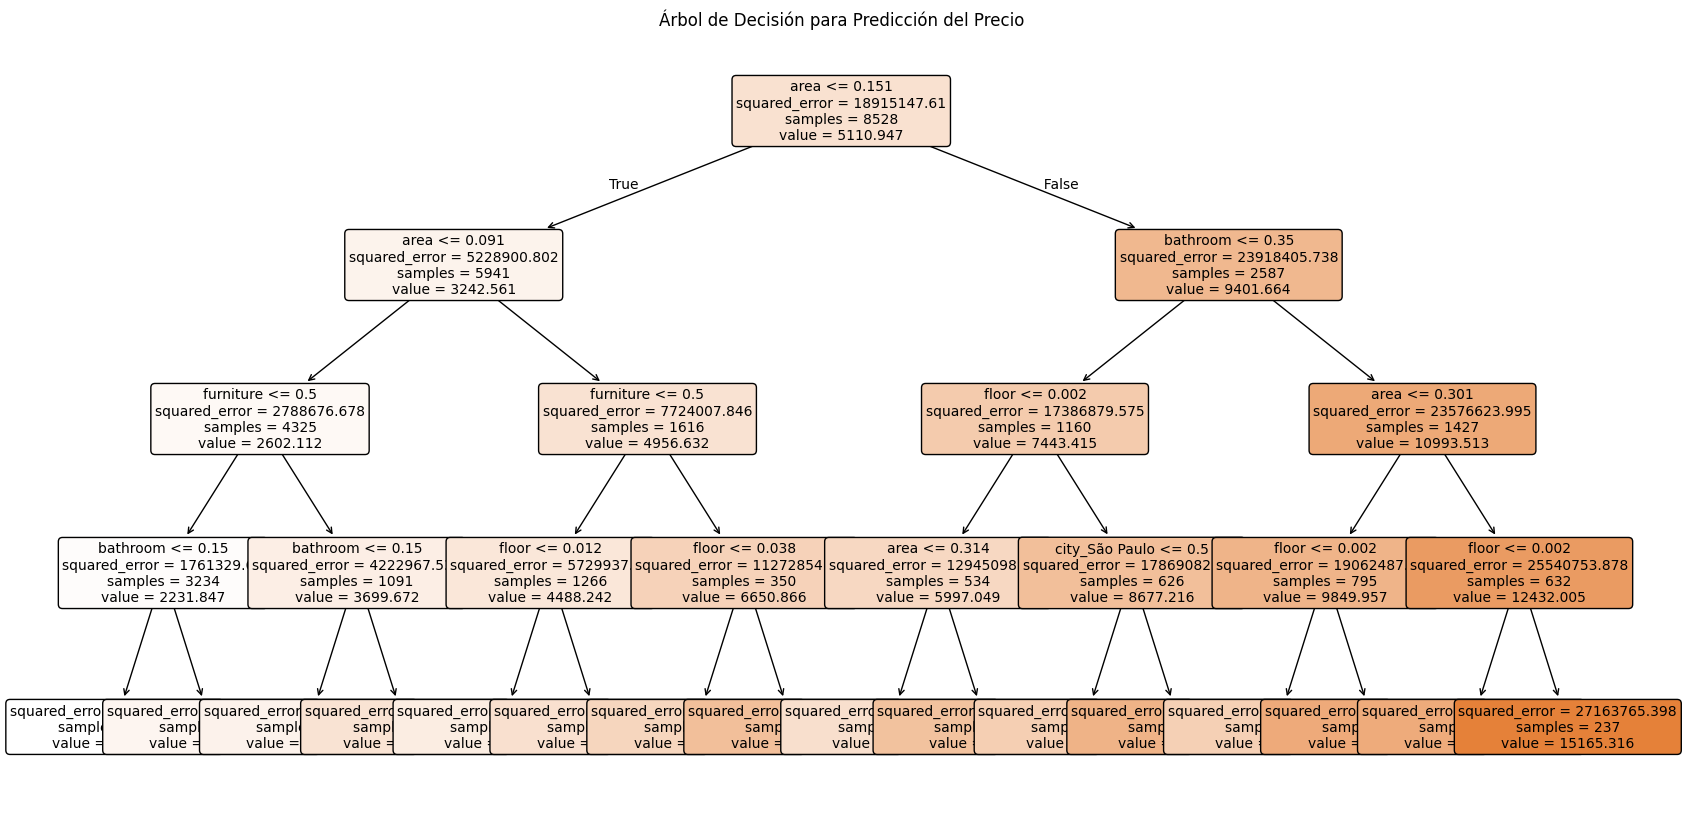

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20, 10))
plot_tree(tree_model,
feature_names=x.columns,
filled=True,
rounded=True,
fontsize=10)
plt.title("Árbol de Decisión para Predicción del Precio")
plt.show()

##**Random Forest Regressor**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
tiempoI3 = time.time()
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)
tiempoF3=time.time()

In [ ]:
y_pred_rf = rf_model.predict(x_test)
r2_rf = r2_score(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
print(f"Coeficiente de determinación (R²): {r2_rf:.2f}")
print(f"Error cuadrático medio (MSE): {mse_rf:.2f}")
print(f"Raíz del Error cuadrático medio (RMSE): {rmse_rf:.2f}")
print(f"Tiempo de ejecución: {tiempoF3-tiempoI3} segundos")

Coeficiente de determinación (R²): 0.68
Error cuadrático medio (MSE): 6813016.62
Raíz del Error cuadrático medio (RMSE): 2610.18
Tiempo de ejecución: 2.714961051940918 segundos


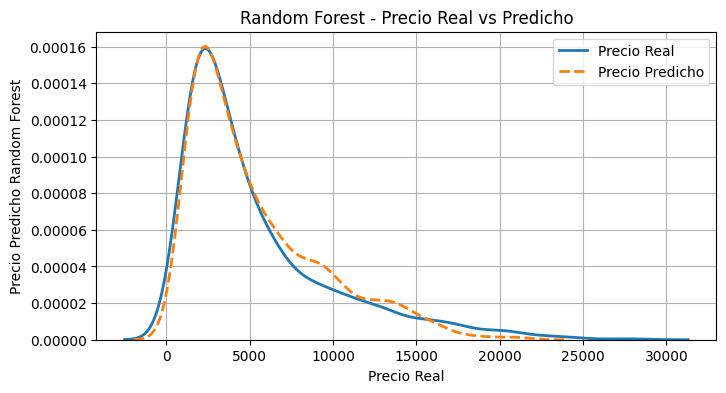

In [ ]:
plt.figure(figsize=(8, 4))
sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred_rf, label='Precio Predicho', linewidth=2, linestyle='--')
plt.title('Random Forest - Precio Real vs Predicho')
plt.xlabel('Precio Real')
plt.ylabel('Precio Predicho Random Forest')
plt.legend()
plt.grid(True)
plt.show()

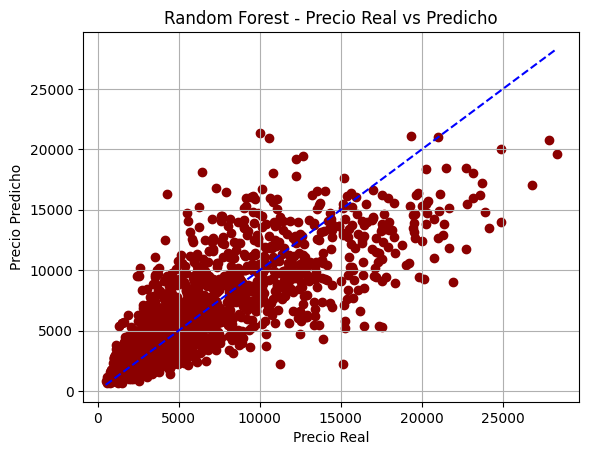

In [ ]:
plt.scatter(y_test, y_pred_rf, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--') # Línea ideal
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Random Forest - Precio Real vs Predicho")
plt.grid(True)
plt.show()

##**Support Vector Regression (SVR)**

In [ ]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_train_scaled = scaler_X.fit_transform(x_train)
X_test_scaled = scaler_X.transform(x_test)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

In [ ]:
tiempoI4 = time.time()
svr_model = SVR(kernel='rbf', C=100, epsilon=0.2)
# Entrenar el modelo con los datos escalados
svr_model.fit(X_train_scaled, y_train_scaled)
tiempoF4=time.time()

In [ ]:
y_pred_scaled = svr_model.predict(X_test_scaled)
y_pred_svr = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))
r2_svr = r2_score(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)
print(f"Coeficiente de determinación (R²): {r2_svr:.2f}")
print(f"Error cuadrático medio (MSE): {mse_svr:.2f}")
print(f"Raíz del Error cuadrático medio (RMSE): {rmse_svr:.2f}")
print(f"Tiempo de ejecución: {tiempoF4-tiempoI4} segundos")


Coeficiente de determinación (R²): 0.67
Error cuadrático medio (MSE): 7130847.57
Raíz del Error cuadrático medio (RMSE): 2670.36
Tiempo de ejecución: 26.472599267959595 segundos


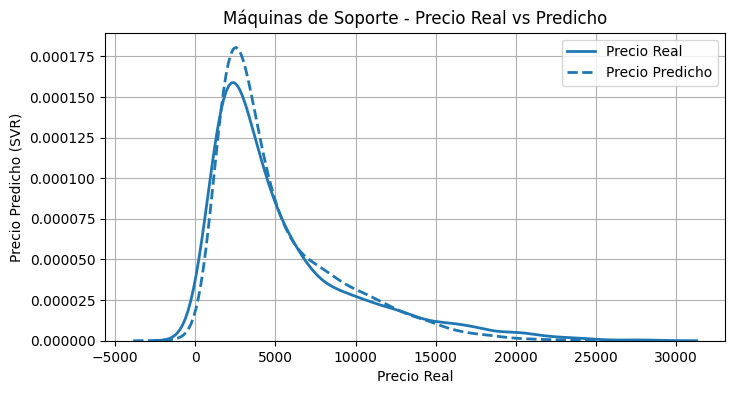

In [ ]:
plt.figure(figsize=(8, 4))
sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred_svr, label='Precio Predicho', linewidth=2, linestyle='--')
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho (SVR)")
plt.title("Máquinas de Soporte - Precio Real vs Predicho")
plt.grid(True)
plt.legend()
plt.show()

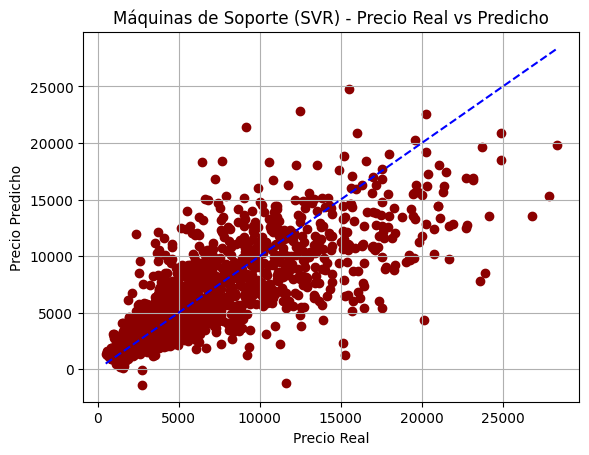

In [ ]:
plt.scatter(y_test, y_pred_svr, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--') #
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Máquinas de Soporte (SVR) - Precio Real vs Predicho")
plt.grid(True)
plt.show()

##**XGBoost Regressor**

In [ ]:
from xgboost import XGBRegressor

In [ ]:
tiempoI5 = time.time()
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3)
xgb_model.fit(x_train, y_train)
tiempoF5=time.time()

In [ ]:
y_pred_xg = xgb_model.predict(x_test)
r2_xg = r2_score(y_test, y_pred_xg)
mse_xg = mean_squared_error(y_test, y_pred_xg)
rmse_xg = np.sqrt(mse_xg)
print(f"Coeficiente de determinación (R²): {r2_xg:.2f}")
print(f"Error cuadrático medio (MSE): {mse_xg:.2f}")
print(f"Raíz del Error cuadrático medio (RMSE): {rmse_xg:.2f}")
print(f"Tiempo de ejecución: {tiempoF5-tiempoI5} segundos")

Coeficiente de determinación (R²): 0.71
Error cuadrático medio (MSE): 6189976.50
Raíz del Error cuadrático medio (RMSE): 2487.97
Tiempo de ejecución: 0.14983654022216797 segundos


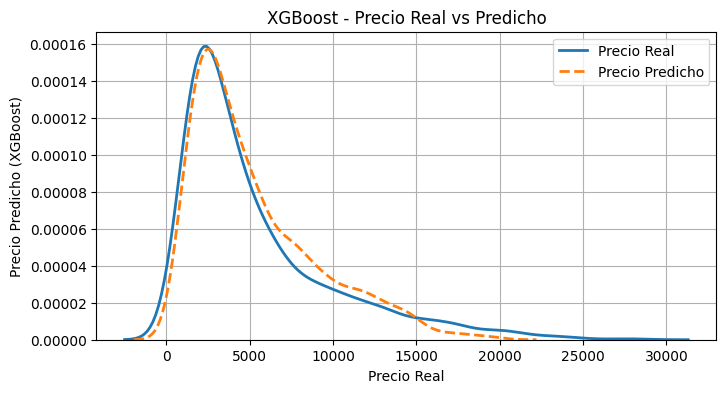

In [ ]:
plt.figure(figsize=(8, 4))
sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred_xg, label='Precio Predicho', linewidth=2, linestyle='--')
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho (XGBoost)")
plt.title("XGBoost - Precio Real vs Predicho")
plt.legend()
plt.grid(True)
plt.show()

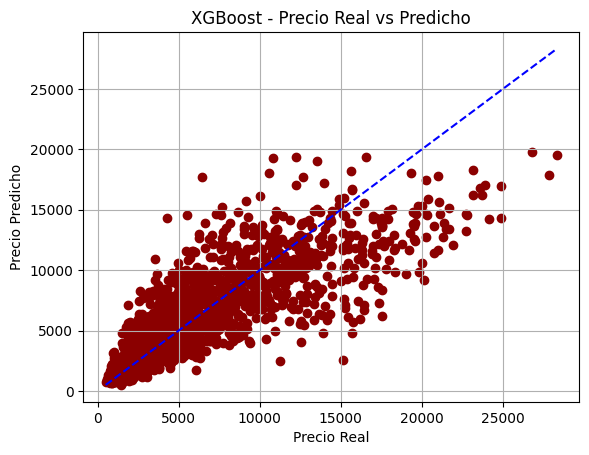

In [ ]:
plt.scatter(y_test, y_pred_xg, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--') # Línea ideal
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("XGBoost - Precio Real vs Predicho")
plt.grid(True)
plt.show()

**Comparación**

In [ ]:
df = pd.DataFrame({
    'Algoritmo': ['RLM', 'ADR', 'RFG', 'SVR', 'XGBoost'],
    'R2 Score': [0.65, 0.62, 0.68, 0.67, 0.71],
    'MSE': [7594637.38, 8244286.08, 6813016.62, 7130847.57, 6189976.50],
    'RMSE': [2755.84, 2871.29, 2610.18, 2670.36, 2487.97],
    'T. Ejecución (s)': [0.03112, 0.01399, 2.60999, 22.87668, 0.66832]
})
df

,Algoritmo,R2 Score,MSE,RMSE,T. Ejecución (s)
0,RLM,0.65,7594637.38,2755.84,0.03112
1,ADR,0.62,8244286.08,2871.29,0.01399
2,RFG,0.68,6813016.62,2610.18,2.60999
3,SVR,0.67,7130847.57,2670.36,22.87668
4,XGBoost,0.71,6189976.50,2487.97,0.66832


#**Fase III: Optimización con IAG y GridSearchCV**

**Árbol de Regresión**

**Alumnos:** Dame tu decisión concisa y fundamentada de los parámetros que debo añadir o modificar en el modelo Árbol de Regresión, junto con el código a adjuntar.

**IA: ChatGPT:**

Con base en tu dataset (variables normalizadas, tamaño ≈10 660 registros y varias variables binarias), la mejor decisión para el árbol de regresión es controlar el sobreajuste agregando hiperparámetros que limiten la complejidad del árbol.
Esto puede ser demasiado restrictivo o no controlar otras formas de sobreajuste.

Decisión recomendada (concisa y fundamentada)

Se deben añadir o modificar estos hiperparámetros:

max_depth	6
Permite capturar relaciones más complejas sin crecer demasiado el árbol.
min_samples_leaf	5
Evita hojas con muy pocos datos, reduciendo overfitting.
min_samples_split	10
Previene divisiones cuando el nodo tiene pocos datos.

Motivo técnico:
Los árboles de decisión tienden a memorizar el conjunto de entrenamiento. Limitar la profundidad y exigir un número mínimo de muestras por nodo mejora la generalización del modelo.

Coeficiente de determinación (R²): 0.65
Error cuadrático medio (MSE): 7454087.70
Raíz del Error cuadrático medio (RMSE): 2730.22
Tiempo de ejecución: 0.019530773162841797 segundos


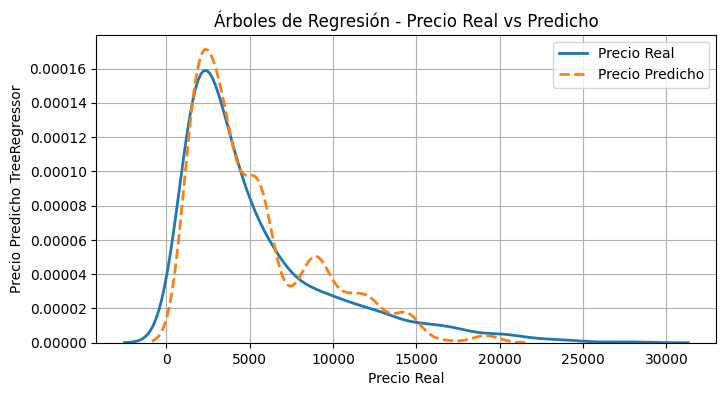

In [ ]:
tiempoI2 = time.time()

tree_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=6,
    min_samples_leaf=5,
    min_samples_split=10
)

tree_model.fit(x_train, y_train)

tiempoF2 = time.time()

y_pred_tree = tree_model.predict(x_test)

r2_tree = r2_score(y_test, y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)

print(f"Coeficiente de determinación (R²): {r2_tree:.2f}")
print(f"Error cuadrático medio (MSE): {mse_tree:.2f}")
print(f"Raíz del Error cuadrático medio (RMSE): {rmse_tree:.2f}")
print(f"Tiempo de ejecución: {tiempoF2-tiempoI2} segundos")

plt.figure(figsize=(8, 4))
sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred_tree, label='Precio Predicho', linewidth=2, linestyle='--')
plt.title('Árboles de Regresión - Precio Real vs Predicho')
plt.xlabel('Precio Real')
plt.ylabel('Precio Predicho TreeRegressor')
plt.legend()
plt.grid(True)
plt.show()



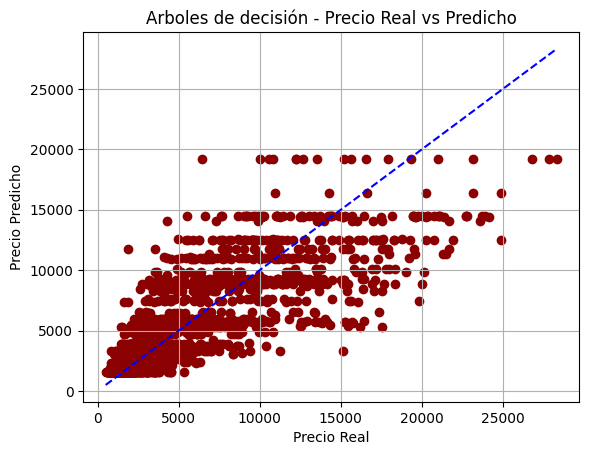

In [ ]:
plt.scatter(y_test, y_pred_tree, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--') # Línea ideal
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Arboles de decisión - Precio Real vs Predicho")
plt.grid(True)
plt.show()

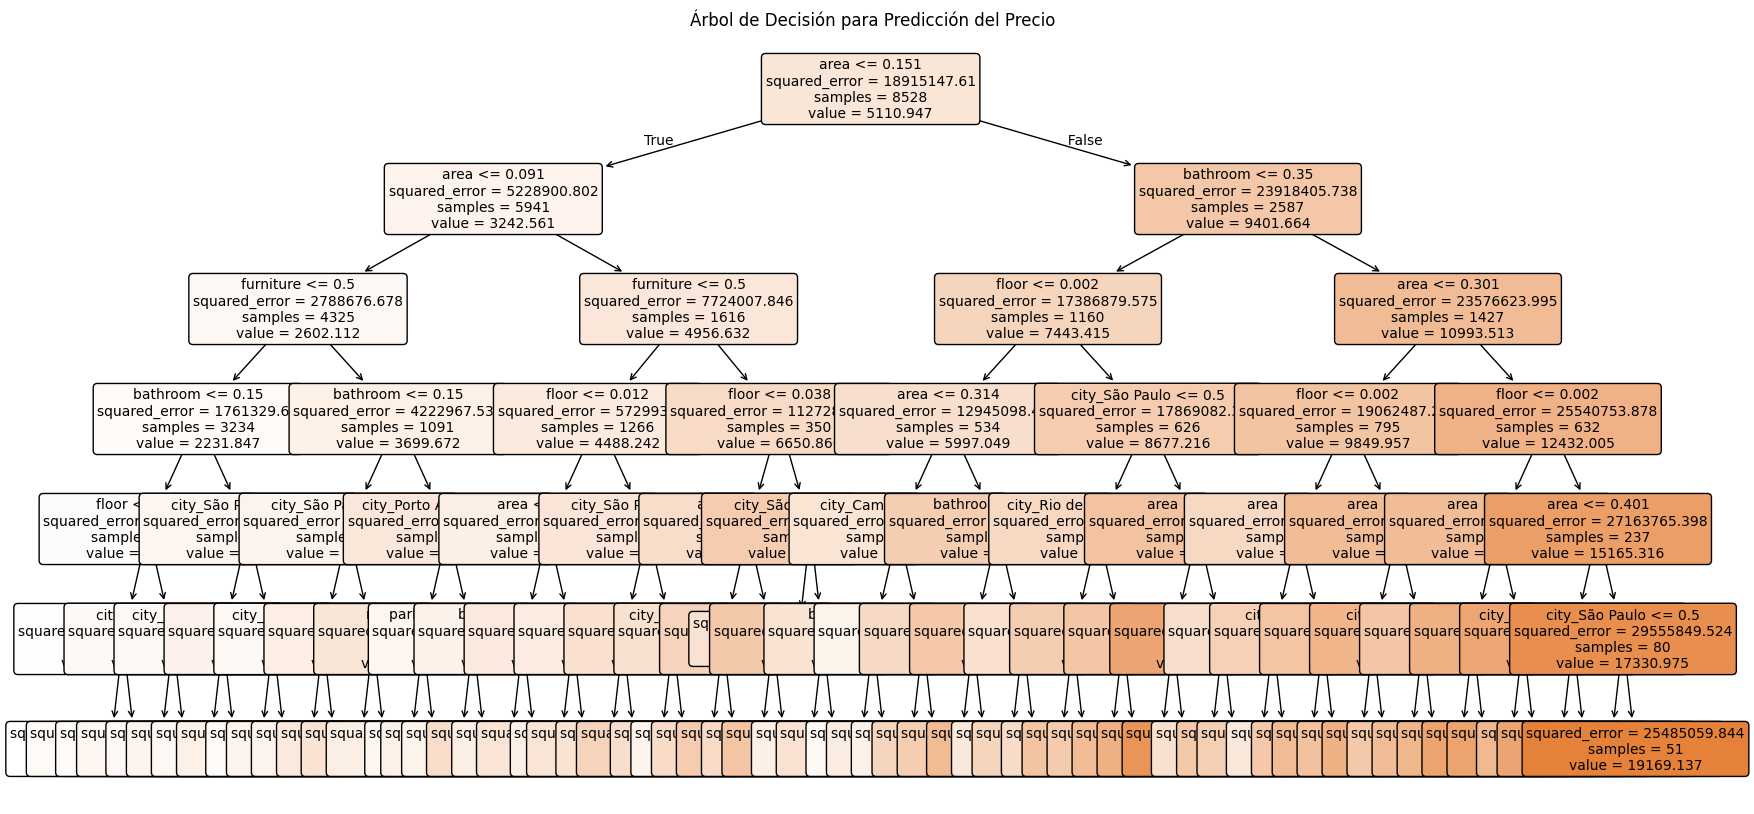

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20, 10))
plot_tree(tree_model,
feature_names=x.columns,
filled=True,
rounded=True,
fontsize=10)
plt.title("Árbol de Decisión para Predicción del Precio")
plt.show()

**Random Forest**

**Alumnos:** Dame tu decisión concisa y fundamentada de los parámetros que debo añadir o modificar en el modelo Random Forest, junto con el código a adjuntar.

**IA: ChatGPT:**

Para tu dataset (≈10660 registros, variables normalizadas y varias binarias), la mejor decisión es reducir el sobreajuste y mejorar la generalización.

Parámetros que se deben añadir o modificar

n_estimators	300
Más árboles reducen la varianza del modelo.

max_depth	12
Limita el crecimiento excesivo de los árboles.

min_samples_leaf	3
Evita hojas con muy pocos datos.

max_features	"sqrt"
Aumenta la diversidad entre árboles.


Para el modelo Random Forest se ajustaron los hiperparámetros n_estimators, max_depth, min_samples_leaf y max_features. Incrementar el número de árboles mejora la estabilidad del modelo, mientras que limitar la profundidad y el número mínimo de muestras por hoja ayuda a reducir el sobreajuste y mejorar la capacidad de generalización.

In [ ]:
tiempoI3 = time.time()

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=3,
    max_features="sqrt",
    random_state=42
)

rf_model.fit(x_train, y_train)

tiempoF3 = time.time()

y_pred_rf = rf_model.predict(x_test)

r2_rf = r2_score(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)

print(f"Coeficiente de determinación (R²): {r2_rf:.2f}")
print(f"Error cuadrático medio (MSE): {mse_rf:.2f}")
print(f"Raíz del Error cuadrático medio (RMSE): {rmse_rf:.2f}")
print(f"Tiempo de ejecución: {tiempoF3-tiempoI3} segundos")

Coeficiente de determinación (R²): 0.71
Error cuadrático medio (MSE): 6147081.91
Raíz del Error cuadrático medio (RMSE): 2479.33
Tiempo de ejecución: 2.002697467803955 segundos


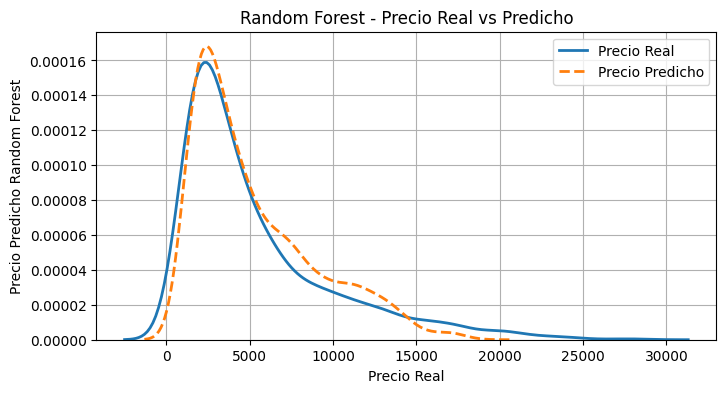

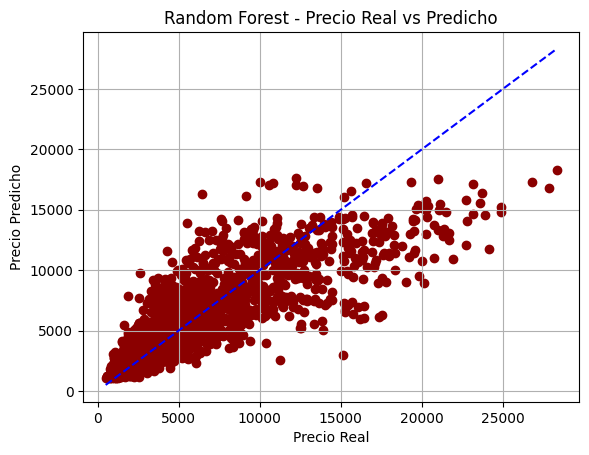

In [ ]:
plt.figure(figsize=(8, 4))
sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred_rf, label='Precio Predicho', linewidth=2, linestyle='--')
plt.title('Random Forest - Precio Real vs Predicho')
plt.xlabel('Precio Real')
plt.ylabel('Precio Predicho Random Forest')
plt.legend()
plt.grid(True)
plt.show()

plt.scatter(y_test, y_pred_rf, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--') # Línea ideal
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Random Forest - Precio Real vs Predicho")
plt.grid(True)
plt.show()

**SVR**

**Alumnos:** Dame tu decisión concisa y fundamentada de los parámetros que debo añadir o modificar en el modelo SVR, junto con el código a adjuntar.

**IA: ChatGPT:**

Faltan dos cosas importantes:

Controlar la influencia de los datos en el kernel (gamma)

Reducir un poco la penalización del error (C) para mejorar generalización


Parámetros recomendados

kernel	"rbf"
Es el kernel más adecuado para relaciones no lineales.

C	50
Reduce riesgo de sobreajuste comparado con 100.

epsilon	0.1
Permite una zona de tolerancia más pequeña para mejorar precisión.

gamma	"scale"
Ajusta automáticamente la influencia de cada punto según la varianza de los datos.

Motivo técnico:
En SVR, C, gamma y epsilon controlan el equilibrio entre complejidad del modelo y tolerancia al error. Ajustarlos permite mejorar la capacidad de generalización del modelo.



In [ ]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(x_train)
X_test_scaled = scaler_X.transform(x_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

tiempoI4 = time.time()

svr_model = SVR(
    kernel='rbf',
    C=50,
    epsilon=0.1,
    gamma='scale'
)

# Entrenar el modelo
svr_model.fit(X_train_scaled, y_train_scaled)

tiempoF4 = time.time()

y_pred_scaled = svr_model.predict(X_test_scaled)

y_pred_svr = scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1))

r2_svr = r2_score(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)

print(f"Coeficiente de determinación (R²): {r2_svr:.2f}")
print(f"Error cuadrático medio (MSE): {mse_svr:.2f}")
print(f"Raíz del Error cuadrático medio (RMSE): {rmse_svr:.2f}")
print(f"Tiempo de ejecución: {tiempoF4-tiempoI4} segundos")

Coeficiente de determinación (R²): 0.68
Error cuadrático medio (MSE): 6928249.15
Raíz del Error cuadrático medio (RMSE): 2632.16
Tiempo de ejecución: 17.63356304168701 segundos


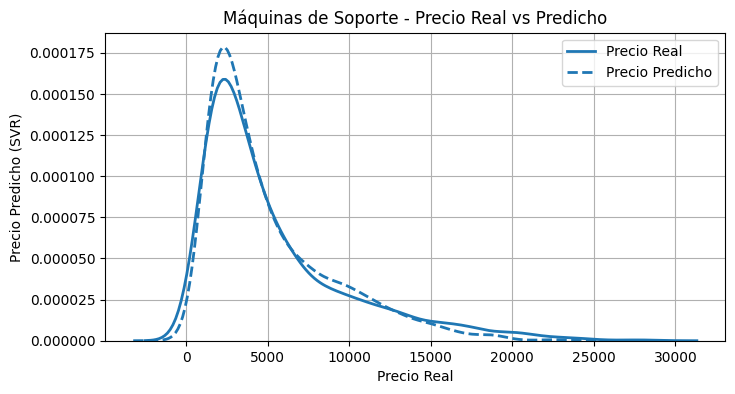

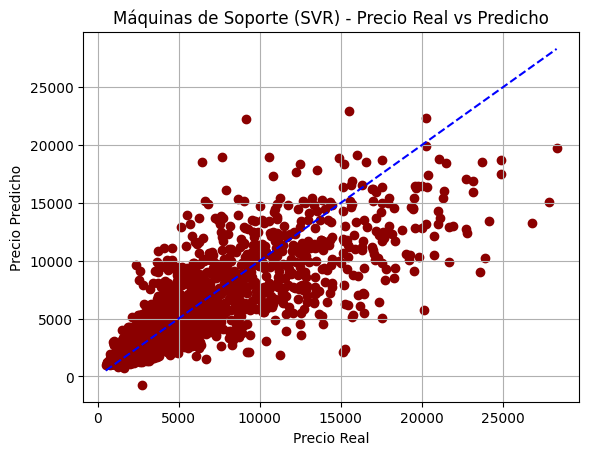

In [ ]:
plt.figure(figsize=(8, 4))
sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred_svr, label='Precio Predicho', linewidth=2, linestyle='--')
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho (SVR)")
plt.title("Máquinas de Soporte - Precio Real vs Predicho")
plt.grid(True)
plt.legend()
plt.show()

plt.scatter(y_test, y_pred_svr, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--') #
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Máquinas de Soporte (SVR) - Precio Real vs Predicho")
plt.grid(True)
plt.show()

**XGBoost**

**Alumnos:** Dame tu decisión concisa y fundamentada de los parámetros que debo añadir o modificar en el modelo XGBoost, junto con el código a adjuntar.

**IA: ChatGPT:**

Para tu dataset (≈10 660 registros, variables numéricas normalizadas y variables dummy), la mejor decisión es aumentar el número de árboles y controlar el sobreajuste mediante muestreo.

Parámetros que se deben modificar o añadir

n_estimators	300
Más árboles mejoran la capacidad predictiva del modelo.

learning_rate	0.05
Reduce la velocidad de aprendizaje para mejorar la generalización.

max_depth	5
Permite capturar relaciones más complejas sin sobreajustar demasiado.

subsample	0.8
Usa solo una parte de los datos por árbol para reducir overfitting.

colsample_bytree	0.8
Usa un subconjunto de variables por árbol, aumentando la robustez del modelo.

Motivo técnico:
XGBoost utiliza boosting secuencial, por lo que reducir el learning_rate y aumentar n_estimators suele mejorar el rendimiento. Además, subsample y colsample_bytree ayudan a evitar el sobreajuste introduciendo aleatoriedad.

In [ ]:
tiempoI5 = time.time()

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(x_train, y_train)

tiempoF5 = time.time()

y_pred_xg = xgb_model.predict(x_test)

r2_xg = r2_score(y_test, y_pred_xg)
mse_xg = mean_squared_error(y_test, y_pred_xg)
rmse_xg = np.sqrt(mse_xg)

print(f"Coeficiente de determinación (R²): {r2_xg:.2f}")
print(f"Error cuadrático medio (MSE): {mse_xg:.2f}")
print(f"Raíz del Error cuadrático medio (RMSE): {rmse_xg:.2f}")
print(f"Tiempo de ejecución: {tiempoF5-tiempoI5} segundos")

Coeficiente de determinación (R²): 0.72
Error cuadrático medio (MSE): 6101373.50
Raíz del Error cuadrático medio (RMSE): 2470.10
Tiempo de ejecución: 0.590665340423584 segundos


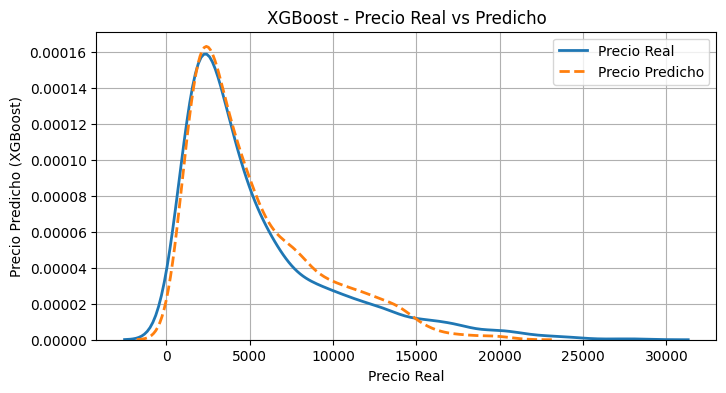

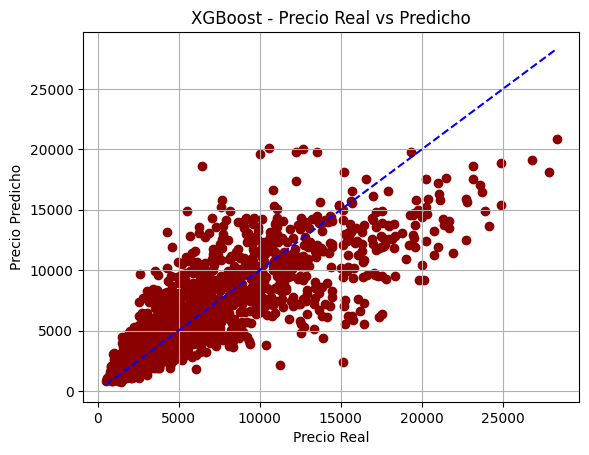

In [ ]:
plt.figure(figsize=(8, 4))
sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred_xg, label='Precio Predicho', linewidth=2, linestyle='--')
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho (XGBoost)")
plt.title("XGBoost - Precio Real vs Predicho")
plt.legend()
plt.grid(True)
plt.show()

plt.scatter(y_test, y_pred_xg, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--') # Línea ideal
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("XGBoost - Precio Real vs Predicho")
plt.grid(True)
plt.show()

In [ ]:
df = pd.DataFrame({
    'Algoritmo': ['RLM', 'ADR', 'RFG', 'SVR', 'XGBoost'],
    'R2 Score': [0.65, 0.65, 0.71, 0.68, 0.72],
    'MSE': [7594637.38, 7454087.70, 6147081.91, 6928249.15, 6101373.50],
    'RMSE': [2755.84, 2730.22, 2479.33, 2632.16, 2470.10],
    'T. Ejecución (s)': [0.03112, 0.023028, 2.84083, 17.29487, 0.76964]
})
df

,Algoritmo,R2 Score,MSE,RMSE,T. Ejecución (s)
0,RLM,0.65,7594637.38,2755.84,0.031120
1,ADR,0.65,7454087.70,2730.22,0.023028
2,RFG,0.71,6147081.91,2479.33,2.840830
3,SVR,0.68,6928249.15,2632.16,17.294870
4,XGBoost,0.72,6101373.50,2470.10,0.769640


**XGBoost Optimizado**

Concluimos en esta parte del proyecto que los dos modelos con mejores resultados son : **Random Forest** y **XGBoost**.

##**GridSearchCV en la combinación de Random Forest y XGBoost**

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
# Modelo base
rf = RandomForestRegressor(random_state=42)

# Grid de hiperparámetros a probar
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [8, 12, 16],
    "min_samples_leaf": [1, 3, 5],
    "max_features": ["sqrt", "log2"]
}

# Configuración de GridSearch
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

# Entrenamiento con búsqueda de hiperparámetros
grid_search.fit(x_train, y_train)

# Mejor modelo encontrado
best_rf = grid_search.best_estimator_

# Predicciones
y_pred_rf = best_rf.predict(x_test)

# Tiempo final
tiempoF3 = time.time()

# Métricas de evaluación
r2_rf = r2_score(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)

# Resultados
print("Mejores parámetros encontrados:", grid_search.best_params_)
print(f"Mejor R² en validación cruzada: {grid_search.best_score_:.2f}")

print(f"\nCoeficiente de determinación (R²): {r2_rf:.2f}")
print(f"Error cuadrático medio (MSE): {mse_rf:.2f}")
print(f"Raíz del Error cuadrático medio (RMSE): {rmse_rf:.2f}")

print(f"\nTiempo de ejecución: {tiempoF3 - tiempoI3} segundos")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Mejores parámetros encontrados: {'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'n_estimators': 300}
Mejor R² en validación cruzada: 0.69

Coeficiente de determinación (R²): 0.71
Error cuadrático medio (MSE): 6147081.91
Raíz del Error cuadrático medio (RMSE): 2479.33

Tiempo de ejecución: 5687.900976657867 segundos


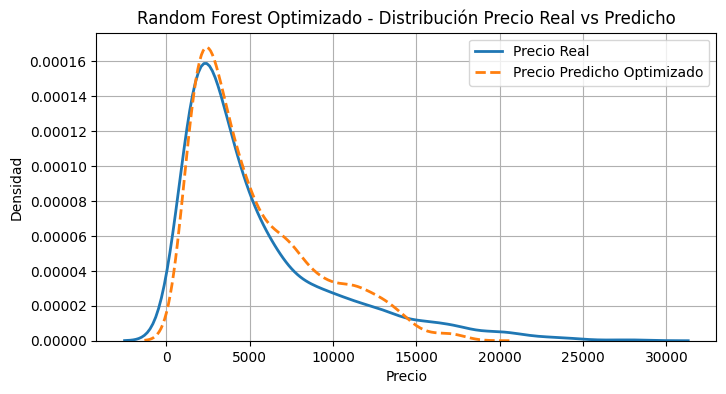

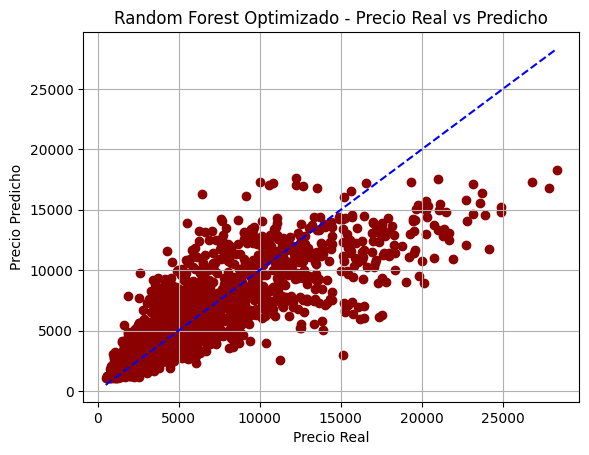

In [ ]:
plt.figure(figsize=(8,4))
sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred_rf, label='Precio Predicho Optimizado', linewidth=2, linestyle='--')
plt.title('Random Forest Optimizado - Distribución Precio Real vs Predicho')
plt.xlabel('Precio')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True)
plt.show()

plt.scatter(y_test, y_pred_rf, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--') # Línea ideal
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Random Forest Optimizado - Precio Real vs Predicho")
plt.grid(True)
plt.show()

**Ahora es turno de encontrar la configuración óptima para que el XGBoost**



In [ ]:
# Tiempo inicial
tiempoI5 = time.time()

# Modelo base
xgb = XGBRegressor(
    random_state=42,
    objective="reg:squarederror"
)
# Grid de hiperparámetros a probar
param_grid = {
    "n_estimators": [200, 300],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [4, 5, 6],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}
# Configuración de GridSearch
grid_search_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

# Entrenamiento con búsqueda de hiperparámetros
grid_search_xgb.fit(x_train, y_train)

# Mejor modelo encontrado
best_xgb = grid_search_xgb.best_estimator_

# Predicciones optimizadas
y_pred_xg = best_xgb.predict(x_test)

# Tiempo final
tiempoF5 = time.time()

# Métricas
r2_xg = r2_score(y_test, y_pred_xg)
mse_xg = mean_squared_error(y_test, y_pred_xg)
rmse_xg = np.sqrt(mse_xg)

# Resultados
print("Mejores parámetros encontrados:")
print(grid_search_xgb.best_params_)
print(f"\nMejor R² en validación cruzada: {grid_search_xgb.best_score_:.2f}")
print(f"\nCoeficiente de determinación (R²): {r2_xg:.2f}")
print(f"Error cuadrático medio (MSE): {mse_xg:.2f}")
print(f"Raíz del Error cuadrático medio (RMSE): {rmse_xg:.2f}")
print(f"\nTiempo de ejecución: {tiempoF5 - tiempoI5} segundos")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Mejores parámetros encontrados:
{'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}

Mejor R² en validación cruzada: 0.70

Coeficiente de determinación (R²): 0.72
Error cuadrático medio (MSE): 6023051.00
Raíz del Error cuadrático medio (RMSE): 2454.19

Tiempo de ejecución: 77.75769472122192 segundos


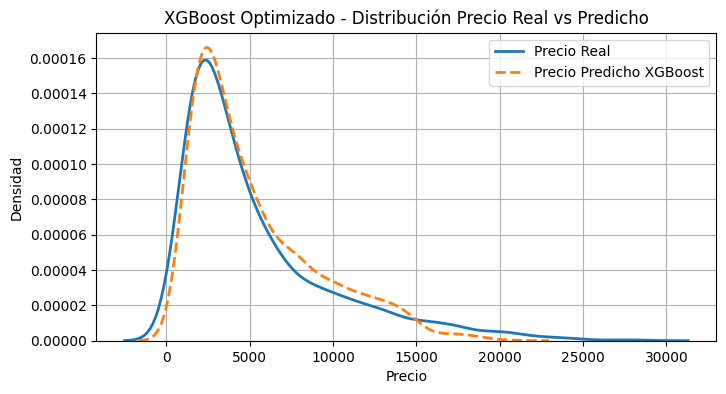

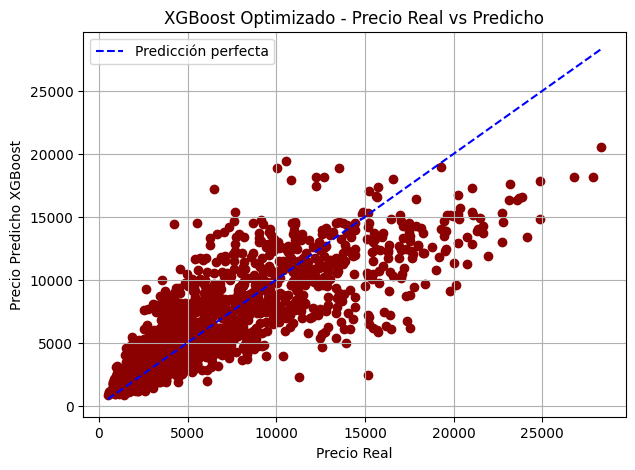

In [ ]:
plt.figure(figsize=(8,4))
sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred_xg, label='Precio Predicho XGBoost', linewidth=2, linestyle='--')
plt.title('XGBoost Optimizado - Distribución Precio Real vs Predicho')
plt.xlabel('Precio')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred_xg, color='darkred')
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'b--',
    label='Predicción perfecta'
)
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho XGBoost")
plt.title("XGBoost Optimizado - Precio Real vs Predicho")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd

df = pd.DataFrame({
    'Algoritmo': ['RLM', 'ADR', 'RFG (GridSearch)', 'SVR', 'XGBoost (GridSearch)'],
    'R2 Score': [ 0.65, 0.65, 0.71, 0.68, 0.72],
    'MSE': [7594637.38, 7454087.70, 6147081.91, 6928249.15, 6023051.00],
    'RMSE': [2755.84,2730.22,2479.33,2632.16,2454.19],
    'T. Ejecución (s)': [0.03112,0.023028,2601.844877719879,17.29487,77.75769472122192]
})
df

,Algoritmo,R2 Score,MSE,RMSE,T. Ejecución (s)
0,RLM,0.65,7594637.38,2755.84,0.031120
1,ADR,0.65,7454087.70,2730.22,0.023028
2,RFG (GridSearch),0.71,6147081.91,2479.33,2601.844878
3,SVR,0.68,6928249.15,2632.16,17.294870
4,XGBoost (GridSearch),0.72,6023051.00,2454.19,77.757695


#**Conclusiones**

##**¿Qué modelo tuvo el mejor desempeño y por qué creen que se adapta mejor a la naturaleza de esos datos?**
El modelo que obtuvo el mejor desempeño fue XGBoost, logrando un coeficiente de determinación de 0.71 en su versión inicial y 0.72 después de haberlo optimizado con GridSearchCV. Se considera que se adapta mejor a la naturaleza de estos datos porque su arquitectura permite capturar relaciones complejas entre variables sin sobreajustar el modelo excesivamente, además el uso de parámetros como "subsample" y "colsample_bytree" permite al algoritmo entrenar con subconjuntos de datos y variables, lo que aumenta su robustez frente a la gran variación que se presenta en el dataset. También notamos que la reducción del tasa de aprendizaje combinada con un aumento de árboles mejora significativamente su capacidad de predicción en comparación con modelos más simples.

##**¿Cómo influyó el uso de la IAG en la selección de parámetros para el GridSearchCV?**
La Inteligencia Artificial Generativa ChatGPT funcionó como una guía técnica para proponer los hiperparámetros iniciales antes de realizar búsquedas exhaustivas donde se sugirió usar parámetros específicos (como max_depth, min_samples_leaf y n_estimators) fundamentados en el tamaño del dataset (10693 registros en total) y el hecho de que las variables estaban normalizadas y eran mayormente binarias.También proporcionó la lógica para limitar la complejidad de los modelos evitando que los árboles "memoricen" los datos, así como también la mejora en la tolerancia al error en modelos como SVR.

##**¿Existe una relación justificada entre el tiempo de ejecución y la precisión obtenida?**
Según los resultados obtenidos, no existe una relación lineal directa que indique que a mayor tiempo de ejecución se obtenga mayor precisiónEl modelo XGBoost optimizado logró la mayor precisión (R2: 0.72) en solo 0.76 segundos, mientras que el modelo SVR tomó mucho más tiempo (17.29 segundos) para una precisión menor (R2: 0.68).

Sin embargo, se observa que la búsqueda exhaustiva de la "configuración óptima" mediante GridSearchCV sí requiere una inversión de tiempo masiva. Por ejemplo, el proceso de encontrar los mejores parámetros para Random Forest tomó 2,601 segundos y en otro intento hasta los 5,687 para alcanzar un R2 de 0.71.

Conluimos que aunque los modelos más precisos son XGBoost y Random Forest requieren más cómputo que una regresión lineal simple, el algoritmo de XGBoost demuestra ser el más eficiente al ofrecer la mayor precisión con un tiempo de ejecución relativamente bajo.